In [1]:
# Celda 1 — carga
import json, numpy as np
import matplotlib.pyplot as plt

with open('results.json') as f:
    data = json.load(f)

print('Datos cargados:', data['generated_at'])

Datos cargados: 2026-05-25 17:07


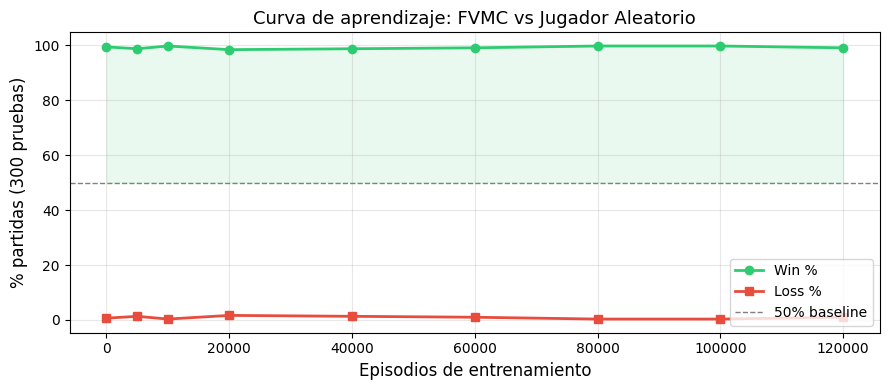

In [2]:
# Celda 2 — Gráfica 1: curva de aprendizaje
pts = data['exp1_learning_curve']
eps = [p['episodes'] for p in pts]
wrs = [p['win_pct']*100 for p in pts]
lrs = [p['loss_pct']*100 for p in pts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(eps, wrs, 'o-', color='#2ecc71', lw=2, ms=6, label='Win %')
ax.plot(eps, lrs, 's-', color='#e74c3c', lw=2, ms=6, label='Loss %')
ax.axhline(50, color='gray', ls='--', lw=1, label='50% baseline')
ax.fill_between(eps, wrs, 50, where=[w > 50 for w in wrs], alpha=0.1, color='#2ecc71')
ax.set_xlabel('Episodios de entrenamiento', fontsize=12)
ax.set_ylabel('% partidas (300 pruebas)', fontsize=12)
ax.set_title('Curva de aprendizaje: FVMC vs Jugador Aleatorio', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig1_learning_curve.png', dpi=150); plt.show()

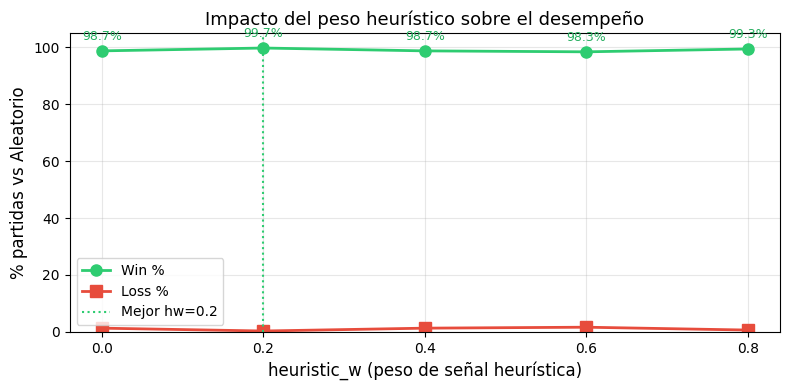

In [3]:
# Celda 3 — Gráfica 2: impacto de heuristic_w
pts = data['exp2_heuristic_w']
hw_vals = [p['heuristic_w'] for p in pts]
gwins   = [p['win_pct']*100 for p in pts]
gloss   = [p['loss_pct']*100 for p in pts]
best_hw = hw_vals[gwins.index(max(gwins))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hw_vals, gwins, 'o-', color='#2ecc71', lw=2, ms=8, label='Win %')
ax.plot(hw_vals, gloss, 's-', color='#e74c3c', lw=2, ms=8, label='Loss %')
ax.axvline(best_hw, color='#2ecc71', ls=':', lw=1.5, label=f'Mejor hw={best_hw}')
for hv, gw in zip(hw_vals, gwins):
    ax.annotate(f'{gw:.1f}%', (hv, gw), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color='#27ae60')
ax.set_xlabel('heuristic_w (peso de señal heurística)', fontsize=12)
ax.set_ylabel('% partidas vs Aleatorio', fontsize=12)
ax.set_title('Impacto del peso heurístico sobre el desempeño', fontsize=13)
ax.set_xticks(hw_vals); ax.set_ylim(0, 105)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig2_heuristic_w.png', dpi=150); plt.show()

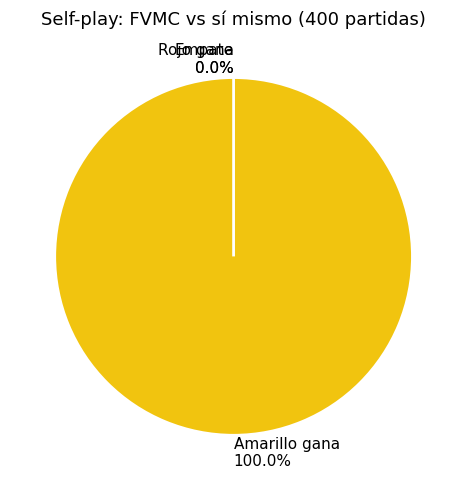

In [4]:
# Celda 4 — Gráfica 3: self-play (pie)
sp    = data['exp3_self_play']
total = sp['red_wins'] + sp['yellow_wins'] + sp['draws']
sizes  = [sp['red_wins'], sp['yellow_wins'], sp['draws']]
labels = [f"Rojo gana\n{sp['red_pct']*100:.1f}%",
          f"Amarillo gana\n{sp['yellow_pct']*100:.1f}%",
          f"Empate\n{sp['draws']/total*100:.1f}%"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(sizes, labels=labels, colors=['#e74c3c','#f1c40f','#95a5a6'],
       startangle=90, textprops={'fontsize': 11},
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Self-play: FVMC vs sí mismo (400 partidas)', fontsize=13)
plt.tight_layout(); plt.savefig('fig3_selfplay.png', dpi=150); plt.show()

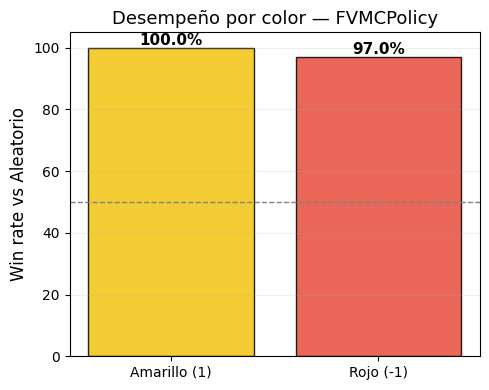

In [5]:
# Celda 5 — Gráfica 4: desempeño por color
bc = data['exp4_by_color']
colores = ['Amarillo (1)', 'Rojo (-1)']
valores = [bc['yellow']*100, bc['red']*100]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(colores, valores, color=['#f1c40f', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.axhline(50, color='gray', ls='--', lw=1)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105); ax.set_ylabel('Win rate vs Aleatorio', fontsize=12)
ax.set_title('Desempeño por color — FVMCPolicy', fontsize=13)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.savefig('fig4_by_color.png', dpi=150); plt.show()

In [6]:
# Celda 6 — Resumen
print('='*50)
best = max(data['exp1_learning_curve'], key=lambda p: p['win_pct'])
print(f"Mejor win rate vs random : {best['win_pct']*100:.1f}% ({best['episodes']:,} ep)")
best_hw = max(data['exp2_heuristic_w'], key=lambda p: p['win_pct'])
print(f"Mejor heuristic_w        : {best_hw['heuristic_w']} → {best_hw['win_pct']*100:.1f}% WR")
sp = data['exp3_self_play']
print(f"Self-play                : Rojo {sp['red_pct']*100:.1f}% / Amarillo {sp['yellow_pct']*100:.1f}%")
bc = data['exp4_by_color']
print(f"Por color vs random      : Amarillo {bc['yellow']*100:.1f}% / Rojo {bc['red']*100:.1f}%")

Mejor win rate vs random : 99.7% (10,000 ep)
Mejor heuristic_w        : 0.2 → 99.7% WR
Self-play                : Rojo 0.0% / Amarillo 100.0%
Por color vs random      : Amarillo 100.0% / Rojo 97.0%
